In [1]:

# =============================================================================
# 1. LIBRARIES
# =============================================================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from feature_engine.outliers import Winsorizer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from xgboost import XGBRegressor
import joblib

In [2]:
# =============================================================================
# 2. CONFIGURATION
# =============================================================================
DATA_PATH   = r"C:\Users\anipi\Downloads\House-Prediction_Project\india_housing_prices.csv"
OUTPUT_DIR  = r"C:\Users\anipi\OneDrive\Documents\House-Prediction_Project"
TARGET_COL  = "price_in_lakhs"
ID_COL      = "id"
RANDOM_SEED = 42
TEST_SIZE   = 0.20

os.makedirs(OUTPUT_DIR, exist_ok=True)


In [3]:
# =============================================================================
# 3. DATA LOADING
# =============================================================================
print("=" * 60)
print("STEP 1 – Loading Data")
print("=" * 60)

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower().str.strip()

print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())

STEP 1 – Loading Data
Shape   : (250000, 23)
Columns : ['id', 'state', 'city', 'locality', 'property_type', 'bhk', 'size_in_sqft', 'price_in_lakhs', 'price_per_sqft', 'year_built', 'furnished_status', 'floor_no', 'total_floors', 'age_of_property', 'nearby_schools', 'nearby_hospitals', 'public_transport_accessibility', 'parking_space', 'security', 'amenities', 'facing', 'owner_type', 'availability_status']

Data Types:
 id                                  int64
state                              object
city                               object
locality                           object
property_type                      object
bhk                                 int64
size_in_sqft                        int64
price_in_lakhs                    float64
price_per_sqft                    float64
year_built                          int64
furnished_status                   object
floor_no                            int64
total_floors                        int64
age_of_property                

In [4]:

# =============================================================================
# 4. EDA – STATISTICAL SUMMARY
# =============================================================================
print("\n" + "=" * 60)
print("STEP 2 – Statistical Summary")
print("=" * 60)

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if ID_COL in num_cols:
    num_cols.remove(ID_COL)

num_df = df[num_cols]

stats_summary = pd.DataFrame({
    "Mean"     : num_df.mean(),
    "Median"   : num_df.median(),
    "Mode"     : num_df.mode().iloc[0],
    "Variance" : num_df.var(),
    "Std_Dev"  : num_df.std(),
    "Skewness" : num_df.skew(),
    "Kurtosis" : num_df.kurtosis(),
})

stats_path = os.path.join(OUTPUT_DIR, "numerical_stats_summary.csv")
stats_summary.to_csv(stats_path)
print(stats_summary)
print(f"\nStats summary saved → {stats_path}")



STEP 2 – Statistical Summary
                         Mean   Median     Mode      Variance      Std_Dev  \
bhk                  2.999396     3.00     1.00  2.003700e+00     1.415521   
size_in_sqft      2749.813216  2747.00  2098.00  1.691578e+06  1300.606954   
price_in_lakhs     254.586854   253.87    40.22  1.997980e+04   141.349921   
price_per_sqft       0.130597     0.09     0.05  1.709484e-02     0.130747   
year_built        2006.520012  2007.00  2023.00  9.620815e+01     9.808575   
floor_no            14.966800    15.00    20.00  8.006754e+01     8.948047   
total_floors        15.503004    15.00    24.00  7.519696e+01     8.671618   
age_of_property     18.479988    18.00     2.00  9.620815e+01     9.808575   
nearby_schools       5.499860     5.00     1.00  8.286561e+00     2.878639   
nearby_hospitals     5.498016     5.00     4.00  8.247581e+00     2.871860   

                  Skewness  Kurtosis  
bhk               0.000543 -1.301396  
size_in_sqft      0.000796 -1.200


STEP 3 – EDA Visualizations


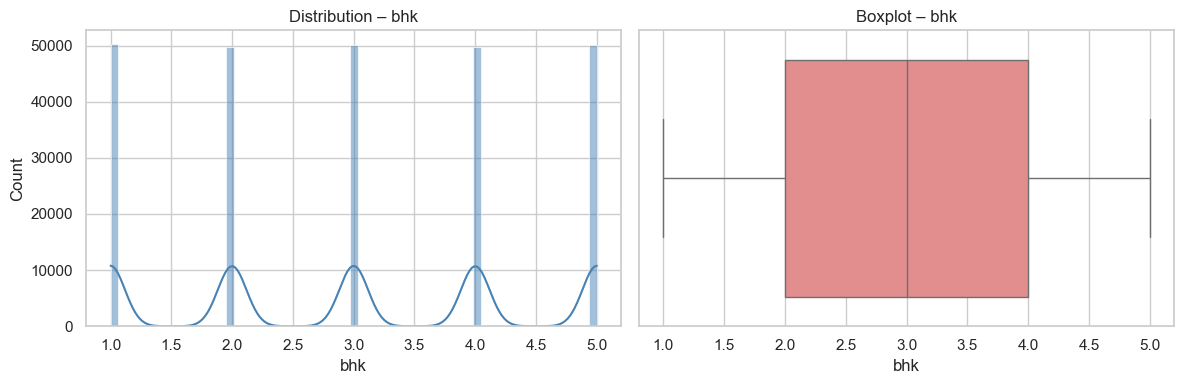

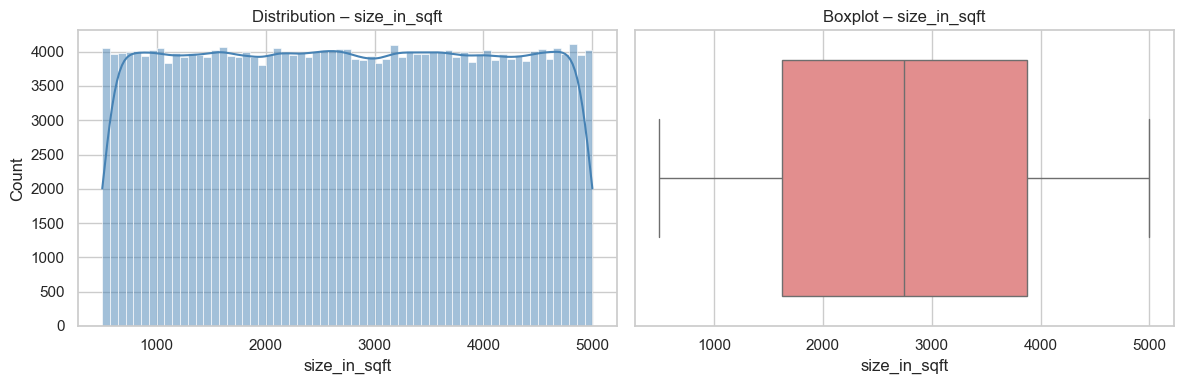

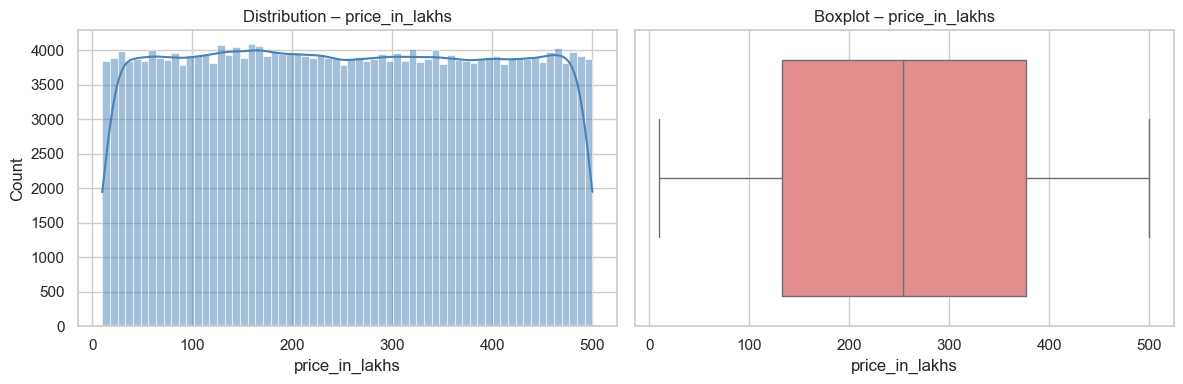

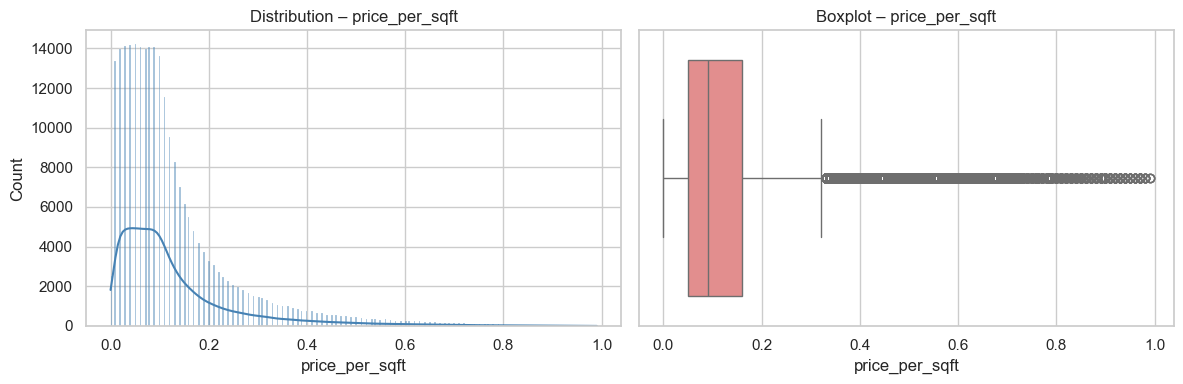

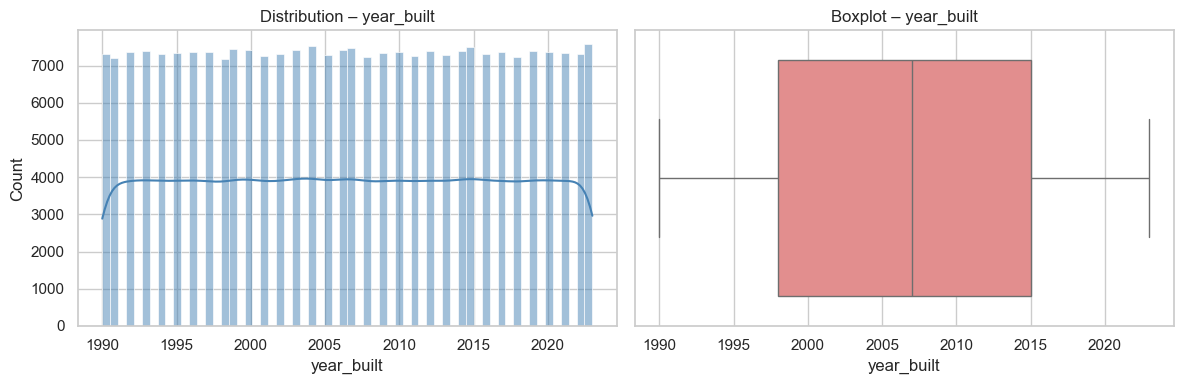

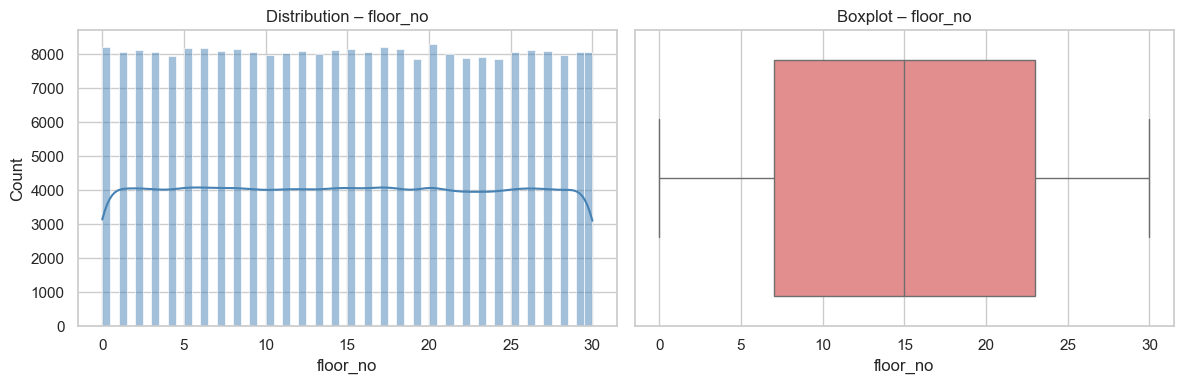

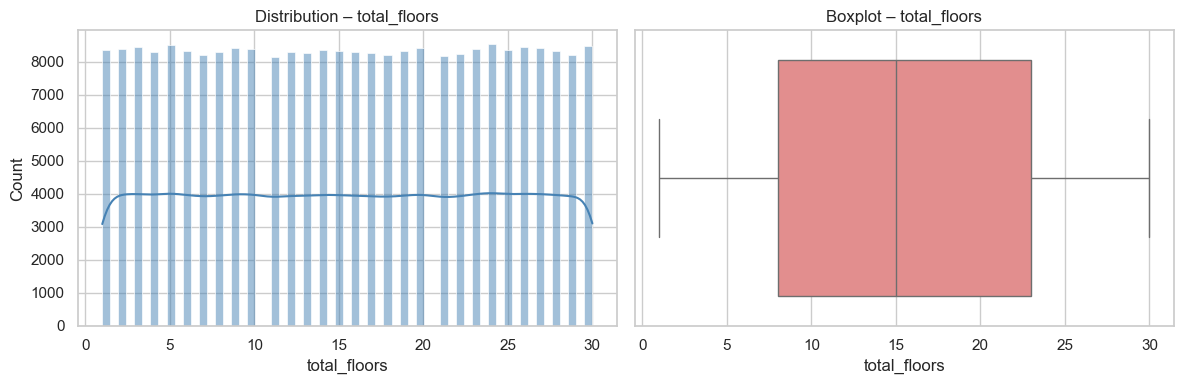

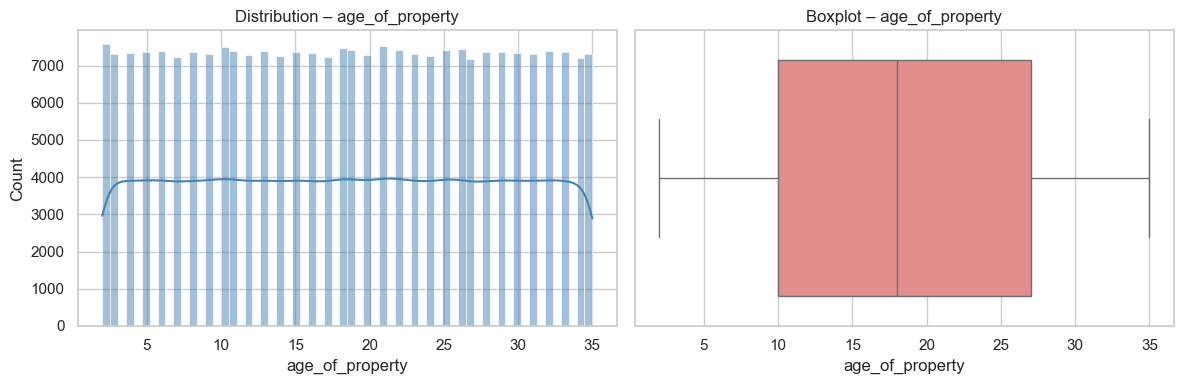

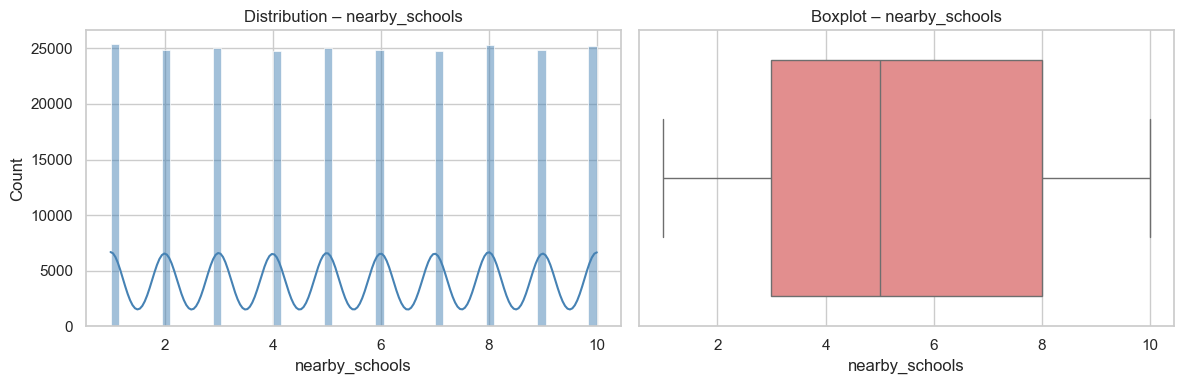

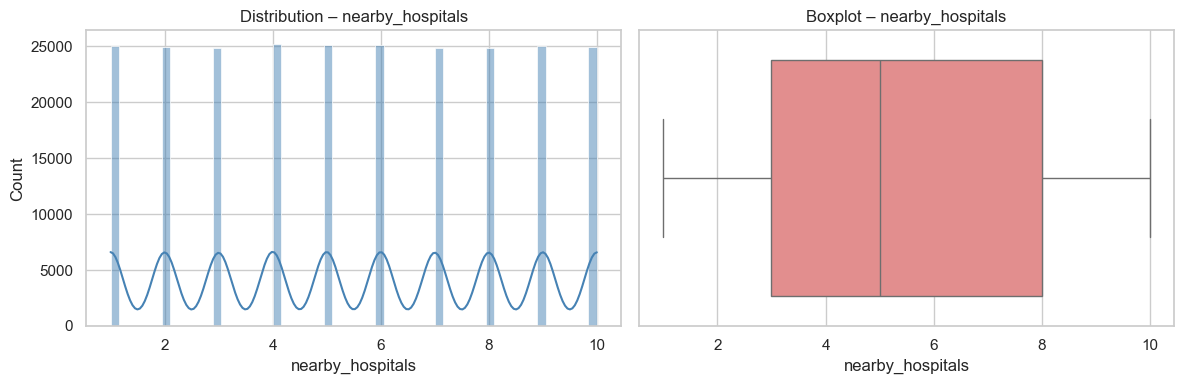

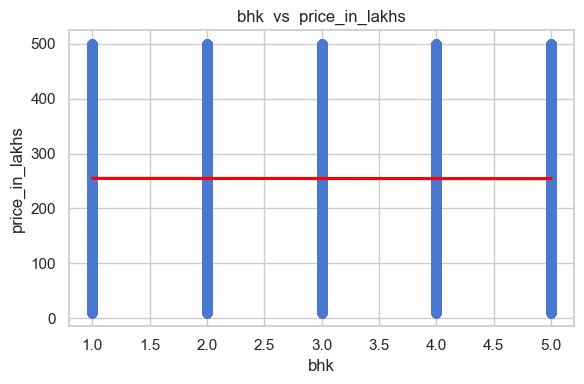

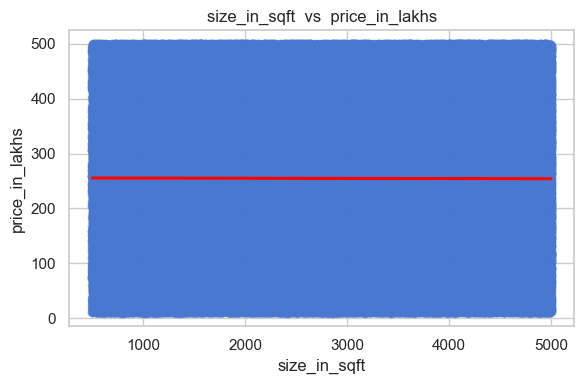

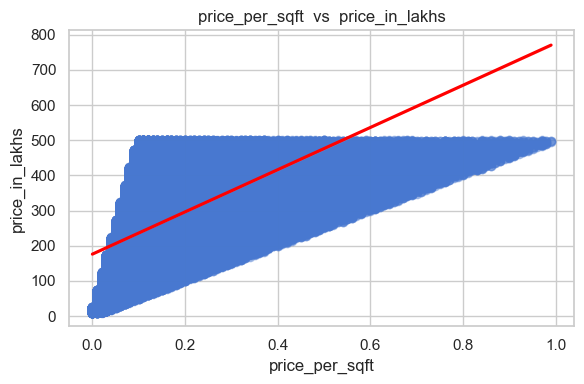

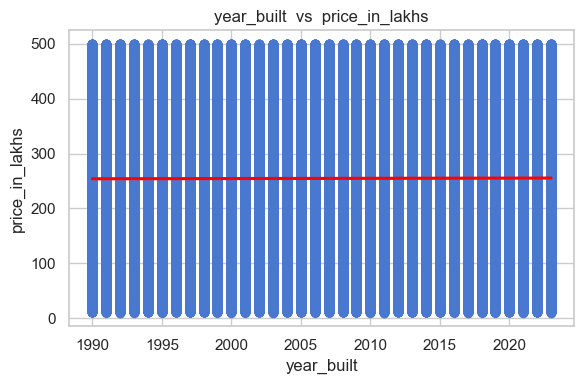

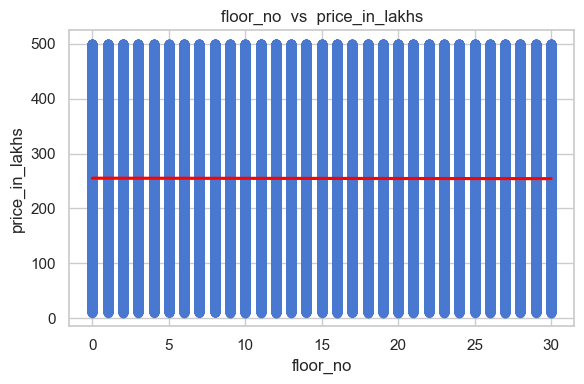

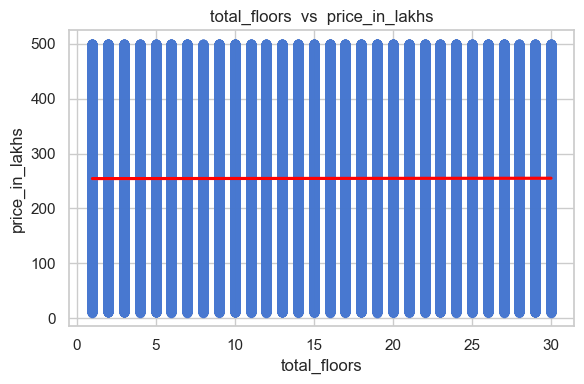

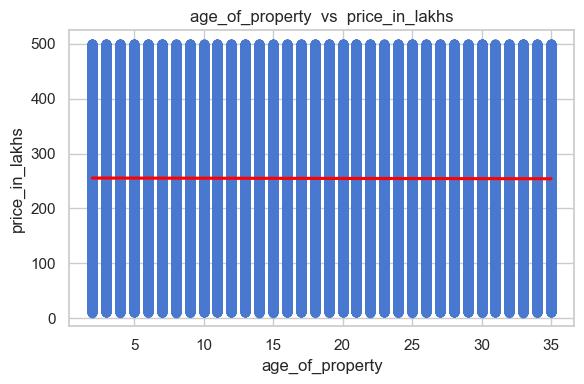

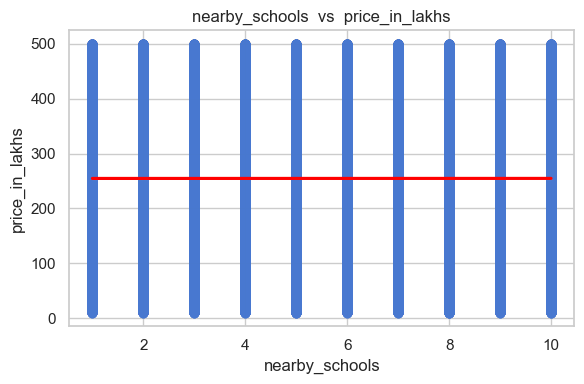

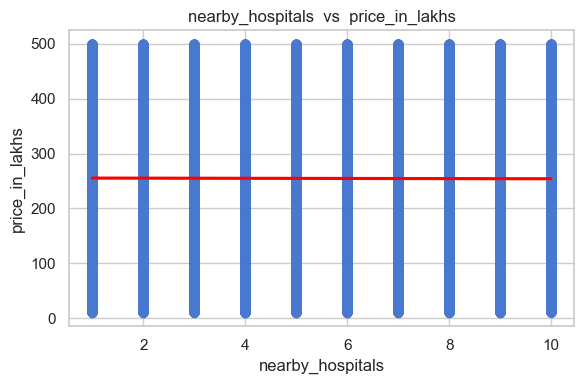

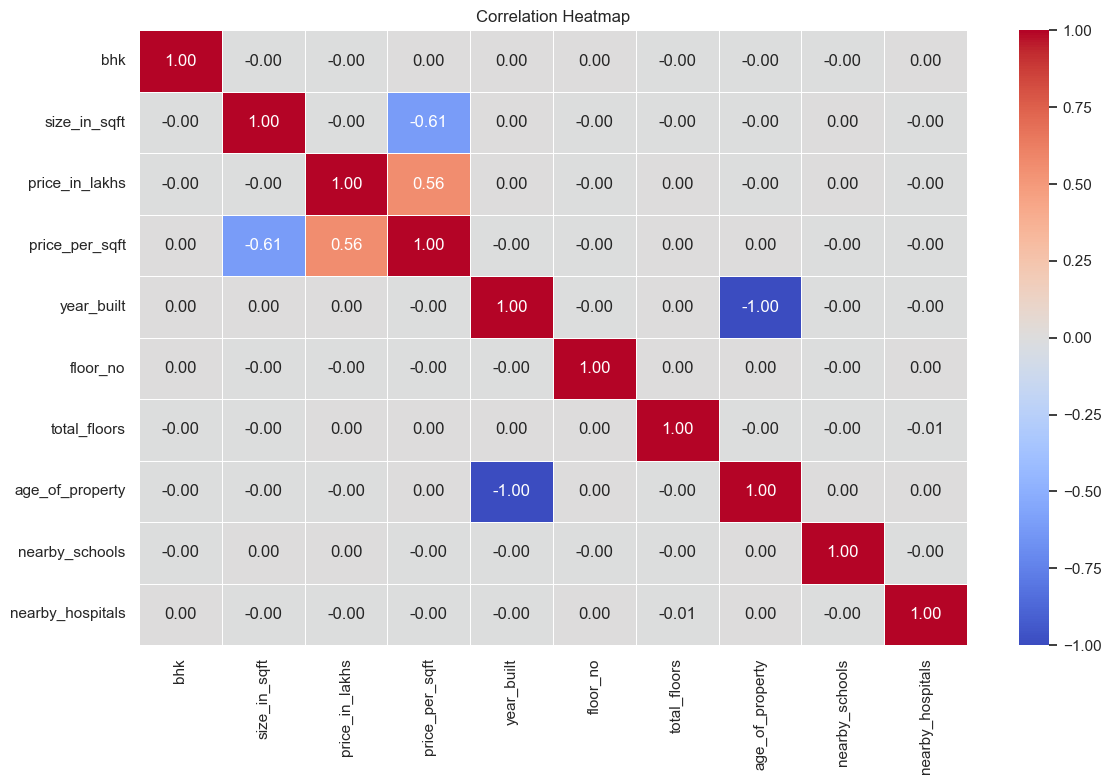

All EDA charts saved.


In [5]:
# =============================================================================
# 5. EDA – VISUALIZATIONS
# =============================================================================
print("\n" + "=" * 60)
print("STEP 3 – EDA Visualizations")
print("=" * 60)

sns.set_theme(style="whitegrid", palette="muted")

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(num_df[col], kde=True, ax=axes[0], color="steelblue")
    axes[0].set_title(f"Distribution – {col}")
    sns.boxplot(x=num_df[col], ax=axes[1], color="lightcoral")
    axes[1].set_title(f"Boxplot – {col}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"eda_univariate_{col}.png"), dpi=100)
    plt.show()
    plt.close()

for col in num_cols:
    if col == TARGET_COL:
        continue
    plt.figure(figsize=(6, 4))
    sns.regplot(x=num_df[col], y=num_df[TARGET_COL],
                scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
    plt.title(f"{col}  vs  {TARGET_COL}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"eda_bivariate_{col}.png"), dpi=100)
    plt.show()
    plt.close()

plt.figure(figsize=(12, 8))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_correlation_heatmap.png"), dpi=100)
plt.show()
plt.close()

print("All EDA charts saved.")


In [6]:
# =============================================================================
# 6. OUTLIER HANDLING
# =============================================================================
print("\n" + "=" * 60)
print("STEP 4 – Outlier Handling (Winsorization IQR × 1.5)")
print("=" * 60)

winsor = Winsorizer(capping_method="iqr", tail="both", fold=1.5, variables=num_cols)
df[num_cols] = winsor.fit_transform(df)[num_cols]
print("Winsorization complete.")



STEP 4 – Outlier Handling (Winsorization IQR × 1.5)
Winsorization complete.


In [7]:

# =============================================================================
# 7. MISSING VALUES & DUPLICATES
# =============================================================================
print("\n" + "=" * 60)
print("STEP 5 – Missing Values & Duplicate Removal")
print("=" * 60)

before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed : {before - len(df)} rows")

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
cat_cols_raw = df.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols_raw:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:", df.isnull().sum().sum(), "total nulls")



STEP 5 – Missing Values & Duplicate Removal
Duplicates removed : 0 rows
Missing values after imputation: 0 total nulls


In [8]:

# =============================================================================
# 8. SAVE CLEANED DATA
# =============================================================================
cleaned_path = os.path.join(OUTPUT_DIR, "india_housing_prices_cleaned.csv")
df.to_csv(cleaned_path, index=False)
print(f"Cleaned data saved → {cleaned_path}")

# =============================================================================
# 9. FEATURE ENGINEERING & SPLIT
# =============================================================================
print("\n" + "=" * 60)
print("STEP 6 – Feature Engineering")
print("=" * 60)

if "price_per_sqft" in df.columns and "size_in_sqft" in df.columns:
    df["price_size_interaction"] = df["price_per_sqft"] * df["size_in_sqft"]
    print("Created feature: price_size_interaction")

drop_cols = [TARGET_COL]
if ID_COL in df.columns:
    drop_cols.append(ID_COL)

X = df.drop(columns=drop_cols)
y = np.log1p(df[TARGET_COL])

feat_num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
feat_cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numerical features  ({len(feat_num_cols)}) : {feat_num_cols}")
print(f"Categorical features ({len(feat_cat_cols)}) : {feat_cat_cols}")


Cleaned data saved → C:\Users\anipi\OneDrive\Documents\House-Prediction_Project\india_housing_prices_cleaned.csv

STEP 6 – Feature Engineering
Created feature: price_size_interaction
Numerical features  (10) : ['bhk', 'size_in_sqft', 'price_per_sqft', 'year_built', 'floor_no', 'total_floors', 'age_of_property', 'nearby_schools', 'nearby_hospitals', 'price_size_interaction']
Categorical features (12) : ['state', 'city', 'locality', 'property_type', 'furnished_status', 'public_transport_accessibility', 'parking_space', 'security', 'amenities', 'facing', 'owner_type', 'availability_status']


In [9]:
# =============================================================================
# 10. PREPROCESSING PIPELINES
# =============================================================================
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, feat_num_cols),
    ("cat", cat_pipeline, feat_cat_cols),
])


In [10]:

# =============================================================================
# 11. TRAIN-TEST SPLIT
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)
print(f"\nTrain : {X_train.shape}   Test : {X_test.shape}")

# =============================================================================
# 12. FIT PREPROCESSOR
# =============================================================================
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)



Train : (200000, 22)   Test : (50000, 22)


In [11]:
# =============================================================================
# 13. MODEL DEFINITIONS
# =============================================================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (α=1)":       Ridge(alpha=1.0),
    "Lasso (α=0.01)":    Lasso(alpha=0.01, max_iter=5000),
    "XGBoost": XGBRegressor(
        n_estimators=50,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        n_jobs=-1,
        objective="reg:squarederror",
        random_state=42,
        verbosity=0,
    ),
}


In [12]:

# =============================================================================
# 14. TRAIN & EVALUATE ALL MODELS
# =============================================================================
print("\n" + "=" * 60)
print("STEP 10 – Training & Evaluation")
print("=" * 60)

results       = {}
trained_models = {}   # ← store fitted estimators

for name, model in models.items():
    print(f"  Training  →  {name} …", end=" ", flush=True)
    model.fit(X_train_proc, y_train)
    y_pred = model.predict(X_test_proc)

    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name]        = {"R2": r2, "MAE": mae, "RMSE": rmse}
    trained_models[name] = model
    print(f"R² = {r2:.4f}  |  MAE = {mae:.4f}  |  RMSE = {rmse:.4f}")

results_df = (
    pd.DataFrame(results).T.round(4).sort_values("R2", ascending=False)
)
print("\n Model Comparison ")
print(results_df.to_string())

metrics_path = os.path.join(OUTPUT_DIR, "model_results.csv")
results_df.to_csv(metrics_path)
print(f"\nMetrics saved → {metrics_path}")



STEP 10 – Training & Evaluation
  Training  →  Linear Regression … R² = 0.8434  |  MAE = 0.2396  |  RMSE = 0.3218
  Training  →  Ridge (α=1) … R² = 0.8434  |  MAE = 0.2396  |  RMSE = 0.3217
  Training  →  Lasso (α=0.01) … R² = 0.8431  |  MAE = 0.2373  |  RMSE = 0.3221
  Training  →  XGBoost … R² = 0.9725  |  MAE = 0.0920  |  RMSE = 0.1347

 Model Comparison 
                       R2     MAE    RMSE
XGBoost            0.9725  0.0920  0.1347
Linear Regression  0.8434  0.2396  0.3218
Ridge (α=1)        0.8434  0.2396  0.3217
Lasso (α=0.01)     0.8431  0.2373  0.3221

Metrics saved → C:\Users\anipi\OneDrive\Documents\House-Prediction_Project\model_results.csv


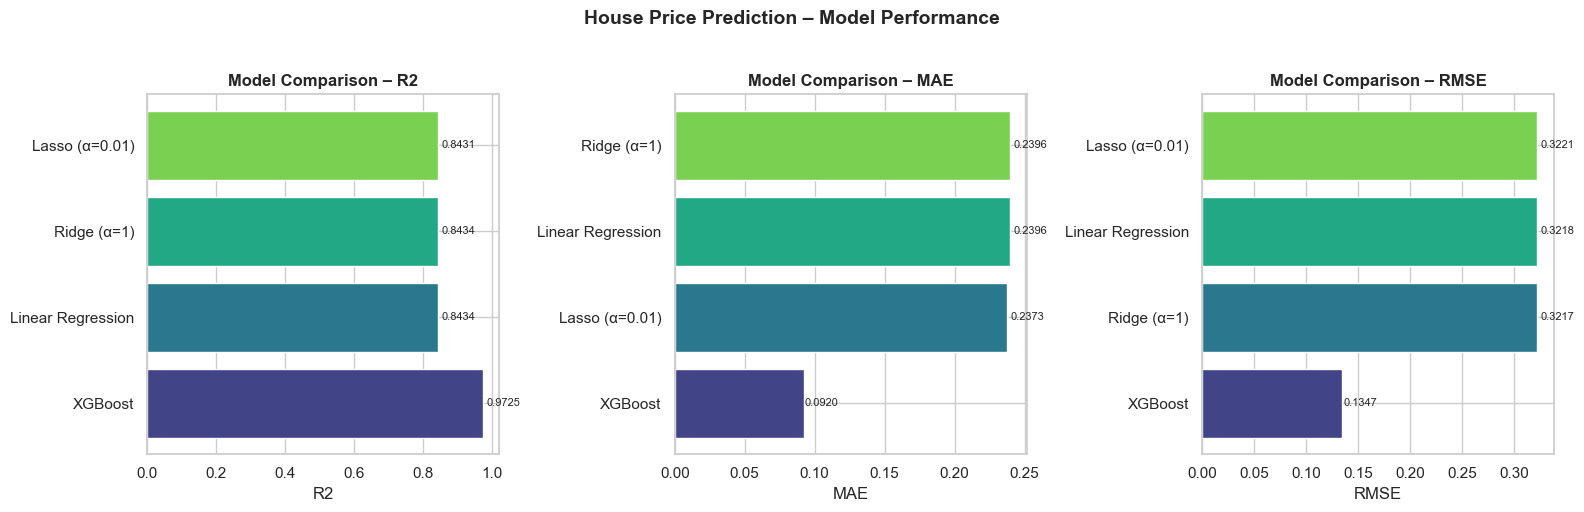

In [13]:

# =============================================================================
# 15. RESULTS VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = sns.color_palette("viridis", len(results_df))

for ax, metric in zip(axes, ["R2", "MAE", "RMSE"]):
    ascending = metric != "R2"
    data = results_df[metric].sort_values(ascending=ascending)
    bars = ax.barh(data.index, data.values, color=palette)
    ax.set_title(f"Model Comparison – {metric}", fontweight="bold")
    ax.set_xlabel(metric)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8)

plt.suptitle("House Price Prediction – Model Performance", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()
plt.close()


In [14]:

# =============================================================================
# 16. FIXED — Save ACTUAL best model (XGBoost) not hardcoded Ridge
# =============================================================================
print("\n" + "=" * 60)
print("STEP 12 – Saving Best Model")
print("=" * 60)

best_model_name = results_df.index[0]   # highest R² — will be XGBoost
print(f"Best model by R² : {best_model_name}")

# Fresh model instances — avoids reusing estimators already fitted on sparse matrix
fresh_models = {
    "Linear Regression": LinearRegression(),
    "Ridge (α=1)":       Ridge(alpha=1.0),
    "Lasso (α=0.01)":    Lasso(alpha=0.01, max_iter=5000),
    "XGBoost": XGBRegressor(
        n_estimators=50,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        n_jobs=-1,
        objective="reg:squarederror",
        random_state=42,
        verbosity=0,
    ),
}

# Build full pipeline with fresh estimator — preprocessor handles raw X_train
best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor",    fresh_models[best_model_name]),  # ✅ fresh instance
])
best_pipeline.fit(X_train, y_train)   # fits preprocessor + model end-to-end

model_path = os.path.join(OUTPUT_DIR, "house_price_model.pkl")
joblib.dump(best_pipeline, model_path)
print(f" Best model pipeline saved → {model_path}")
print(f" Model used: {best_model_name}")



STEP 12 – Saving Best Model
Best model by R² : XGBoost
 Best model pipeline saved → C:\Users\anipi\OneDrive\Documents\House-Prediction_Project\house_price_model.pkl
 Model used: XGBoost


In [15]:

# =============================================================================
# 17. INFERENCE DEMO
# =============================================================================
print("\n" + "=" * 60)
print("STEP 13 – Quick Inference Demo")
print("=" * 60)

loaded_model = joblib.load(model_path)

sample    = X_test.iloc[[0]].copy()
log_pred  = loaded_model.predict(sample)[0]
price_pred = np.expm1(log_pred)
print(f"Sample prediction (log-scale)  : {log_pred:.4f}")
print(f"Sample prediction (lakhs)      : ₹ {price_pred:,.2f} Lakhs")

print("\n" + "=" * 60)
print("PIPELINE COMPLETE  ✓")
print("=" * 60)



STEP 13 – Quick Inference Demo
Sample prediction (log-scale)  : 5.8147
Sample prediction (lakhs)      : ₹ 334.20 Lakhs

PIPELINE COMPLETE  ✓
